# Population Variation and Urban Accessibility in Spanish Municipalities (2011-2024)

**Author:** Juan Zotes Orcajo  
**Date:** February 2026  

---

## Version 4 - Final:
- **Buffers visible**: High transparency on population colors so buffers show through
- **Frame with coordinates**: QGIS-style frame with tick marks on borders
- **Canarias**: In its own box within the main frame
- **Everything inside the frame** except main title

---

## 1. Setup and Imports

In [1]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration

In [2]:
# Paths
BASE_DIR = Path("/workspaces/rural-migration-land-use-spain")
PADRON_PATH = BASE_DIR / "data/demography/processed/01_padron_clean_1996_2024.csv"
VARIATIONS_DIR = BASE_DIR / "data/demography/derived"
SPATIAL_DIR = BASE_DIR / "data/spatial/derived"
GPKG_PATH = SPATIAL_DIR / "mun_geographic_administrative_hierarchy.gpkg"
OUTPUT_DIR = BASE_DIR / "data/maps"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Parameters
CITY_THRESHOLD = 50000
BUFFER_DISTANCES = [30000, 60000]

# CRS
CRS_PENINSULA = "EPSG:25830"
CRS_CANARIAS = "EPSG:32628"
CRS_DISPLAY = "EPSG:4258"

CANARIAS_CODES = ['35', '38']

print(f"✓ Output: {OUTPUT_DIR}")

✓ Output: /workspaces/rural-migration-land-use-spain/data/maps


## 3. Load Data

In [3]:
# Load municipalities
gdf_mun = gpd.read_file(GPKG_PATH)
gdf_mun['Mun_Code'] = gdf_mun['Mun_Code'].astype(str).str.zfill(5)

# Separate by region
gdf_peninsula = gdf_mun[~gdf_mun['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
gdf_canarias = gdf_mun[gdf_mun['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()

# Project to UTM
gdf_peninsula_utm = gdf_peninsula.to_crs(CRS_PENINSULA)
gdf_canarias_utm = gdf_canarias.to_crs(CRS_CANARIAS)

print(f"✓ Loaded {len(gdf_mun):,} municipalities")
print(f"  Peninsula: {len(gdf_peninsula):,} | Canarias: {len(gdf_canarias):,}")

✓ Loaded 8,132 municipalities
  Peninsula: 8,044 | Canarias: 88


In [4]:
# Load population data
df_padron = pd.read_csv(PADRON_PATH, dtype={'Mun_Code': str}, encoding='utf-8')
df_padron['Mun_Code'] = df_padron['Mun_Code'].str.zfill(5)

df_padron_total = df_padron[df_padron['Cat'] == 'Total'].copy()
df_padron_filtered = df_padron_total[df_padron_total['Year'].isin([2017, 2021, 2024])].copy()

df_padron_wide = df_padron_filtered.pivot_table(
    index=['Mun_Code', 'Mun'], columns='Year', values='Pop', aggfunc='first'
).reset_index()
df_padron_wide.columns.name = None
df_padron_wide = df_padron_wide.rename(columns={2017: 'pop_2017', 2021: 'pop_2021', 2024: 'pop_2024'})

print(f"✓ Population data loaded")

✓ Population data loaded


In [5]:
# Load variation data
df_var_k06 = pd.read_csv(VARIATIONS_DIR / "padron_variations_k_06.csv", dtype={'Mun_Code': str})
df_var_k06['Mun_Code'] = df_var_k06['Mun_Code'].str.zfill(5)

df_var_k03 = pd.read_csv(VARIATIONS_DIR / "padron_variations_k_03.csv", dtype={'Mun_Code': str})
df_var_k03['Mun_Code'] = df_var_k03['Mun_Code'].str.zfill(5)

period_data = {
    '2011-2017': df_var_k06[['Mun_Code', 'Mun', 'pop_2011_2017 (k=6)']].rename(columns={'pop_2011_2017 (k=6)': 'var_pct'}),
    '2018-2021': df_var_k03[['Mun_Code', 'Mun', 'pop_2018_2021 (k=3)']].rename(columns={'pop_2018_2021 (k=3)': 'var_pct'}),
    '2021-2024': df_var_k03[['Mun_Code', 'Mun', 'pop_2021_2024 (k=3)']].rename(columns={'pop_2021_2024 (k=3)': 'var_pct'})
}

print("✓ Variation data loaded")

✓ Variation data loaded


## 4. Identify Cities and Create Buffers

In [6]:
def identify_major_cities(df_padron, year_col, threshold=CITY_THRESHOLD):
    cities = df_padron[df_padron[year_col] >= threshold][['Mun_Code', 'Mun', year_col]].copy()
    return cities.rename(columns={year_col: 'pop_reference'})

cities_2017 = identify_major_cities(df_padron_wide, 'pop_2017')
cities_2021 = identify_major_cities(df_padron_wide, 'pop_2021')
cities_2024 = identify_major_cities(df_padron_wide, 'pop_2024')

print(f"✓ Cities: 2017={len(cities_2017)} | 2021={len(cities_2021)} | 2024={len(cities_2024)}")

✓ Cities: 2017=145 | 2021=149 | 2024=152


In [7]:
def create_city_geodataframes_by_region(gdf_pen_utm, gdf_can_utm, cities_df):
    cities_pen = cities_df[~cities_df['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    cities_can = cities_df[cities_df['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    
    gdf_cities_pen = gdf_pen_utm.merge(cities_pen, on='Mun_Code', how='inner')
    gdf_cities_pen['centroid'] = gdf_cities_pen.geometry.centroid
    gdf_cities_pen = gdf_cities_pen.set_geometry('centroid')
    
    gdf_cities_can = gdf_can_utm.merge(cities_can, on='Mun_Code', how='inner')
    if len(gdf_cities_can) > 0:
        gdf_cities_can['centroid'] = gdf_cities_can.geometry.centroid
        gdf_cities_can = gdf_cities_can.set_geometry('centroid')
    
    return gdf_cities_pen, gdf_cities_can

gdf_cities_pen_2017, gdf_cities_can_2017 = create_city_geodataframes_by_region(gdf_peninsula_utm, gdf_canarias_utm, cities_2017)
gdf_cities_pen_2021, gdf_cities_can_2021 = create_city_geodataframes_by_region(gdf_peninsula_utm, gdf_canarias_utm, cities_2021)
gdf_cities_pen_2024, gdf_cities_can_2024 = create_city_geodataframes_by_region(gdf_peninsula_utm, gdf_canarias_utm, cities_2024)

print("✓ City geodataframes created")

✓ City geodataframes created


In [8]:
def create_buffer_zones_by_region(gdf_cities_pen, gdf_cities_can, distances):
    buffers = {}
    for dist in distances:
        buffers[dist] = {}
        
        buffer_geom_pen = gdf_cities_pen.geometry.buffer(dist)
        gdf_buffer_pen = gpd.GeoDataFrame(geometry=[unary_union(buffer_geom_pen)], crs=gdf_cities_pen.crs)
        buffers[dist]['peninsula'] = gdf_buffer_pen
        
        if len(gdf_cities_can) > 0:
            buffer_geom_can = gdf_cities_can.geometry.buffer(dist)
            gdf_buffer_can = gpd.GeoDataFrame(geometry=[unary_union(buffer_geom_can)], crs=gdf_cities_can.crs)
            buffers[dist]['canarias'] = gdf_buffer_can
        else:
            buffers[dist]['canarias'] = gpd.GeoDataFrame()
    return buffers

buffers_2017 = create_buffer_zones_by_region(gdf_cities_pen_2017, gdf_cities_can_2017, BUFFER_DISTANCES)
buffers_2021 = create_buffer_zones_by_region(gdf_cities_pen_2021, gdf_cities_can_2021, BUFFER_DISTANCES)
buffers_2024 = create_buffer_zones_by_region(gdf_cities_pen_2024, gdf_cities_can_2024, BUFFER_DISTANCES)

print("✓ Buffers created with correct CRS")

✓ Buffers created with correct CRS


## 5. Prepare Map Data

In [9]:
def classify_population_change(val):
    if pd.isna(val): return 'No data'
    elif val < -10: return 'Strong decline (< -10%)'
    elif val < -5: return 'Moderate decline (-10% to -5%)'
    elif val < 0: return 'Slight decline (-5% to 0%)'
    elif val < 5: return 'Slight growth (0% to 5%)'
    elif val < 10: return 'Moderate growth (5% to 10%)'
    else: return 'Strong growth (> 10%)'

def prepare_map_data(gdf_mun, period_df):
    gdf = gdf_mun.merge(period_df, on='Mun_Code', how='left')
    gdf['variation_class'] = gdf['var_pct'].apply(classify_population_change)
    return gdf

gdf_map_2011_2017 = prepare_map_data(gdf_mun, period_data['2011-2017'])
gdf_map_2018_2021 = prepare_map_data(gdf_mun, period_data['2018-2021'])
gdf_map_2021_2024 = prepare_map_data(gdf_mun, period_data['2021-2024'])

print("✓ Map data prepared")

✓ Map data prepared


## 6. Styling

In [10]:
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

# Population colors
VARIATION_COLORS = {
    'Strong decline (< -10%)': '#08519C',
    'Moderate decline (-10% to -5%)': '#3182BD',
    'Slight decline (-5% to 0%)': '#9ECAE1',
    'Slight growth (0% to 5%)': '#FCBBA1',
    'Moderate growth (5% to 10%)': '#FC8D59',
    'Strong growth (> 10%)': '#D7301F',
    'No data': '#D9D9D9'
}

VARIATION_ORDER = [
    'Strong growth (> 10%)', 'Moderate growth (5% to 10%)', 'Slight growth (0% to 5%)',
    'Slight decline (-5% to 0%)', 'Moderate decline (-10% to -5%)', 'Strong decline (< -10%)'
]

# KEY: Very high transparency so buffers show through!
POPULATION_ALPHA = 0.69

# Buffer styling - darker and thicker lines
BUFFER_COLORS = {
    30000: '#000000',  # Black
    60000: '#404040',  # Dark gray
}
BUFFER_LINEWIDTH = 1.8

# Cities
CITY_COLOR = '#000000'
CITY_SIZE = 15

print("✓ Styling defined (population alpha={}, buffers visible)".format(POPULATION_ALPHA))

✓ Styling defined (population alpha=0.69, buffers visible)


## 7. Create Map Function (QGIS-style with frame and coordinates)

In [11]:
def create_population_map(
    gdf_map, 
    gdf_cities_pen, 
    gdf_cities_can,
    buffers, 
    period_name, 
    output_path,
    author_name="Juan Zotes Orcajo"
):
    
    # Separate and project data
    gdf_peninsula = gdf_map[~gdf_map['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    gdf_canarias = gdf_map[gdf_map['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    
    gdf_peninsula_plot = gdf_peninsula.to_crs(CRS_DISPLAY)
    gdf_canarias_plot = gdf_canarias.to_crs(CRS_DISPLAY)
    
    # Convert buffers and cities to display CRS
    buffers_display = {}
    for dist in BUFFER_DISTANCES:
        buffers_display[dist] = {
            'peninsula': buffers[dist]['peninsula'].to_crs(CRS_DISPLAY),
            'canarias': buffers[dist]['canarias'].to_crs(CRS_DISPLAY) if not buffers[dist]['canarias'].empty else gpd.GeoDataFrame()
        }
    
    gdf_cities_pen_display = gdf_cities_pen.to_crs(CRS_DISPLAY)
    gdf_cities_can_display = gdf_cities_can.to_crs(CRS_DISPLAY) if len(gdf_cities_can) > 0 else gpd.GeoDataFrame()
    
    # Create figure
    fig = plt.figure(figsize=(14, 12), facecolor='white')
    
    # ============ TITLE ============
    fig.text(0.5, 0.96, f'POPULATION VARIATION IN SPANISH MUNICIPALITIES ({period_name})',
             ha='center', fontsize=15, fontweight='bold')
    fig.text(0.5, 0.935, 'Distance to cities > 50,000 inhabitants',
             ha='center', fontsize=14, style='italic')
    
    # ============ MAIN FRAME ============
    ax_main = fig.add_axes([0.05, 0.16, 0.90, 0.86])
    
    # ============ PLOT PENINSULA ============
    for var_class in VARIATION_ORDER:
        data = gdf_peninsula_plot[gdf_peninsula_plot['variation_class'] == var_class]
        if len(data) > 0:
            data.plot(ax=ax_main, color=VARIATION_COLORS[var_class],
                     edgecolor='white', linewidth=0.05, alpha=POPULATION_ALPHA)
    
    no_data = gdf_peninsula_plot[gdf_peninsula_plot['variation_class'] == 'No data']
    if len(no_data) > 0:
        no_data.plot(ax=ax_main, color=VARIATION_COLORS['No data'],
                    edgecolor='white', linewidth=0.05, alpha=POPULATION_ALPHA)
    
    # Plot buffers
    for dist in reversed(BUFFER_DISTANCES):
        if not buffers_display[dist]['peninsula'].empty:
            buffers_display[dist]['peninsula'].plot(
                ax=ax_main, facecolor='none',
                edgecolor=BUFFER_COLORS[dist],
                linewidth=BUFFER_LINEWIDTH,
                linestyle='--', zorder=5
            )
    
    # Cities
    if len(gdf_cities_pen_display) > 0:
        gdf_cities_pen_display.plot(ax=ax_main, color=CITY_COLOR,
                                    markersize=CITY_SIZE, edgecolor='white',
                                    linewidth=0.5, zorder=10)
    
    # ============ LÍMITES - ZOOM ============
    ax_main.set_xlim(-11, 4.6)       # Desplazamiento Este-Oeste
    ax_main.set_ylim(34.3, 44.2)       # Desplazamiento Norte-Sur
    ax_main.set_aspect('equal')
    
    # ============ TICKS ============
    ax_main.xaxis.set_major_locator(mticker.MultipleLocator(3))
    ax_main.yaxis.set_major_locator(mticker.MultipleLocator(2))
    ax_main.xaxis.set_minor_locator(mticker.NullLocator())
    ax_main.yaxis.set_minor_locator(mticker.NullLocator())
    
    def format_lon(x, pos):
        if x < 0: return f"{abs(x):.0f}°O"
        elif x > 0: return f"{x:.0f}°E"
        else: return "0°"
    
    def format_lat(y, pos):
        return f"{y:.0f}°N"
    
    ax_main.xaxis.set_major_formatter(mticker.FuncFormatter(format_lon))
    ax_main.yaxis.set_major_formatter(mticker.FuncFormatter(format_lat))
    
    ax_main.tick_params(
        axis='both', which='major',
        direction='out', length=5, width=1, labelsize=9,
        bottom=True, left=True, top=False, right=False,
        labelbottom=True, labelleft=True, labeltop=False, labelright=False
    )
    
    # Frame
    for spine in ax_main.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')
    
    # ============ CANARIAS ============
    ax_canarias = ax_main.inset_axes([0.01, -0.025, 0.25, 0.25])
    
    for var_class in VARIATION_ORDER:
        data = gdf_canarias_plot[gdf_canarias_plot['variation_class'] == var_class]
        if len(data) > 0:
            data.plot(ax=ax_canarias, color=VARIATION_COLORS[var_class],
                     edgecolor='white', linewidth=0.03, alpha=POPULATION_ALPHA)
    
    no_data_can = gdf_canarias_plot[gdf_canarias_plot['variation_class'] == 'No data']
    if len(no_data_can) > 0:
        no_data_can.plot(ax=ax_canarias, color=VARIATION_COLORS['No data'],
                        edgecolor='white', linewidth=0.03, alpha=POPULATION_ALPHA)
    
    for dist in reversed(BUFFER_DISTANCES):
        if not buffers_display[dist]['canarias'].empty:
            buffers_display[dist]['canarias'].plot(
                ax=ax_canarias, facecolor='none',
                edgecolor=BUFFER_COLORS[dist],
                linewidth=BUFFER_LINEWIDTH * 0.7,
                linestyle='--', zorder=5
            )
    
    if len(gdf_cities_can_display) > 0:
        gdf_cities_can_display.plot(ax=ax_canarias, color=CITY_COLOR,
                                    markersize=CITY_SIZE * 0.6, edgecolor='white',
                                    linewidth=0.3, zorder=10)
    
    ax_canarias.set_xlim(-18.3, -13.2)
    ax_canarias.set_ylim(27.5, 29.6)
    ax_canarias.set_aspect('equal')
    ax_canarias.set_xticks([])
    ax_canarias.set_yticks([])
    for spine in ax_canarias.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')
    ax_canarias.patch.set_facecolor('white')
    ax_canarias.patch.set_alpha(1)
    
    # ============ NORTH ARROW - MÁS ESTRECHA ============
    ax_north = ax_main.inset_axes([0.96, 0.92, 0.04, 0.06])  # Más estrecha (0.04 en vez de 0.06)
    ax_north.set_xlim(0, 1)
    ax_north.set_ylim(0, 1.5)
    ax_north.axis('off')
    
    # Flecha más estrecha
    arrow_x = [0.5, 0.25, 0.5, 0.75, 0.5]  # Más estrecha (0.25-0.75 en vez de 0.15-0.85)
    arrow_y = [1.4, 0.3, 0.45, 0.3, 1.4]
    ax_north.fill(arrow_x, arrow_y, color='black', edgecolor='black', linewidth=0.5)
    arrow_white_x = [0.5, 0.5, 0.75, 0.5]
    arrow_white_y = [1.4, 0.45, 0.3, 1.4]
    ax_north.fill(arrow_white_x, arrow_white_y, color='white', edgecolor='black', linewidth=0.5)
    ax_north.text(0.5, 0.0, 'N', ha='center', va='top', fontsize=9, fontweight='bold')
    
    # ============ SCALE BAR ============
    scale_x = -4.8
    scale_y = 34.55
    km_to_deg = 1.8 / 200
    
    ax_main.plot([scale_x, scale_x + 200*km_to_deg], [scale_y, scale_y], 'k-', linewidth=2, zorder=20)
    ax_main.plot([scale_x, scale_x], [scale_y - 0.0, scale_y + 0.08], 'k-', linewidth=1.5, zorder=20)
    ax_main.plot([scale_x + 200*km_to_deg, scale_x + 200*km_to_deg], [scale_y - 0.0, scale_y + 0.08], 'k-', linewidth=1.5, zorder=20)
    ax_main.plot([scale_x + 400*km_to_deg, scale_x + 400*km_to_deg], [scale_y - 0.0, scale_y + 0.08], 'k-', linewidth=1.5, zorder=20)
    ax_main.plot([scale_x + 200*km_to_deg, scale_x + 400*km_to_deg], [scale_y, scale_y], 'k-', linewidth=2, zorder=20)
    
    ax_main.text(scale_x, scale_y - 0.08, '0', ha='center', va='top', fontsize=7, zorder=20)
    ax_main.text(scale_x + 200*km_to_deg, scale_y - 0.08, '200', ha='center', va='top', fontsize=7, zorder=20)
    ax_main.text(scale_x + 400*km_to_deg, scale_y - 0.08, '400 km', ha='center', va='top', fontsize=7, zorder=20)
    
    # ============ LEGEND ============
    legend_elements = []

    # ESPACIO DESPUÉS DEL TÍTULO
    legend_elements.append(Line2D([0], [0], color='none', label=''))  # Línea vacía
    
    for var_class in VARIATION_ORDER:
        legend_elements.append(
            mpatches.Patch(facecolor=VARIATION_COLORS[var_class], edgecolor='#666666',
                          linewidth=0.5, alpha=0.85, label=var_class)
        )
    
    legend_elements.append(Line2D([0], [0], color='none', label=''))
    legend_elements.append(Line2D([0], [0], color='none', label='Distance buffers:'))
    
    for dist in BUFFER_DISTANCES:
        legend_elements.append(
            Line2D([0], [0], color=BUFFER_COLORS[dist], linewidth=BUFFER_LINEWIDTH,
                   linestyle='--', label=f'{dist//1000} km from major city')
        )
    
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=CITY_COLOR,
               markeredgecolor='white', markersize=7, linewidth=0,
               label='Cities > 50,000 inhabitants')
    )
    
    # Leyenda posicionada 
    legend = ax_main.legend(
        handles=legend_elements,
        loc='lower right',
        bbox_to_anchor=(0.993, 0.08),  # Posición ajustada
        title='Symbology:',
        title_fontsize=11,
        fontsize=10,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        framealpha=1,
        facecolor='white',
        borderpad=0.6,
        labelspacing=0.3
    )
    legend.get_title().set_fontweight('bold')
    legend.get_frame().set_linewidth(0.8)
    # AÑADE ESTO para alinear el título a la izquierda
    legend._legend_box.align = "left"
    
    # ============ CREDITS - posición ajustada ============
    ax_main.text(4.4, 34.49,
                 f'CRS: ETRS89 (EPSG: 4258)\n'
                 f'Data source: INE (Spanish National Statistics Institute)\n'
                 f'© {author_name}',
                 ha='right', va='bottom', fontsize=8.8, color='#333333', zorder=20)
    
    # Save
    plt.savefig(output_path, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none', pad_inches=0.02)
    
    print(f"✓ Saved: {output_path.name}")
    plt.show()
    plt.close()

print("✓ Map function ready")

✓ Map function ready


## 8. Generate Maps

✓ Saved: map_2011_2017_population_variation.png


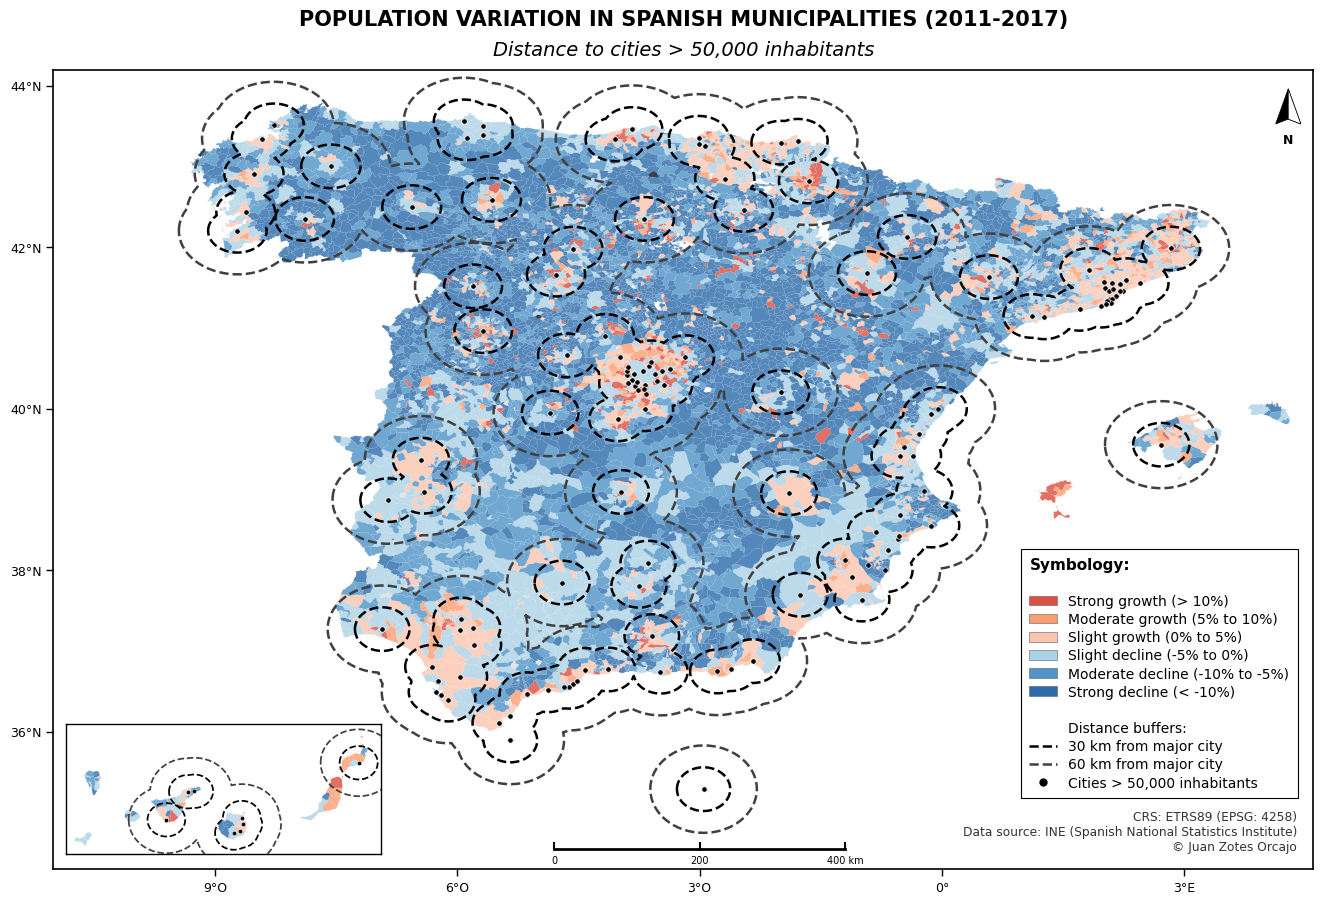

In [12]:
create_population_map(
    gdf_map=gdf_map_2011_2017,
    gdf_cities_pen=gdf_cities_pen_2017,
    gdf_cities_can=gdf_cities_can_2017,
    buffers=buffers_2017,
    period_name='2011-2017',
    output_path=OUTPUT_DIR / 'map_2011_2017_population_variation.png',
    author_name="Juan Zotes Orcajo"
)

✓ Saved: map_2018_2021_population_variation.png


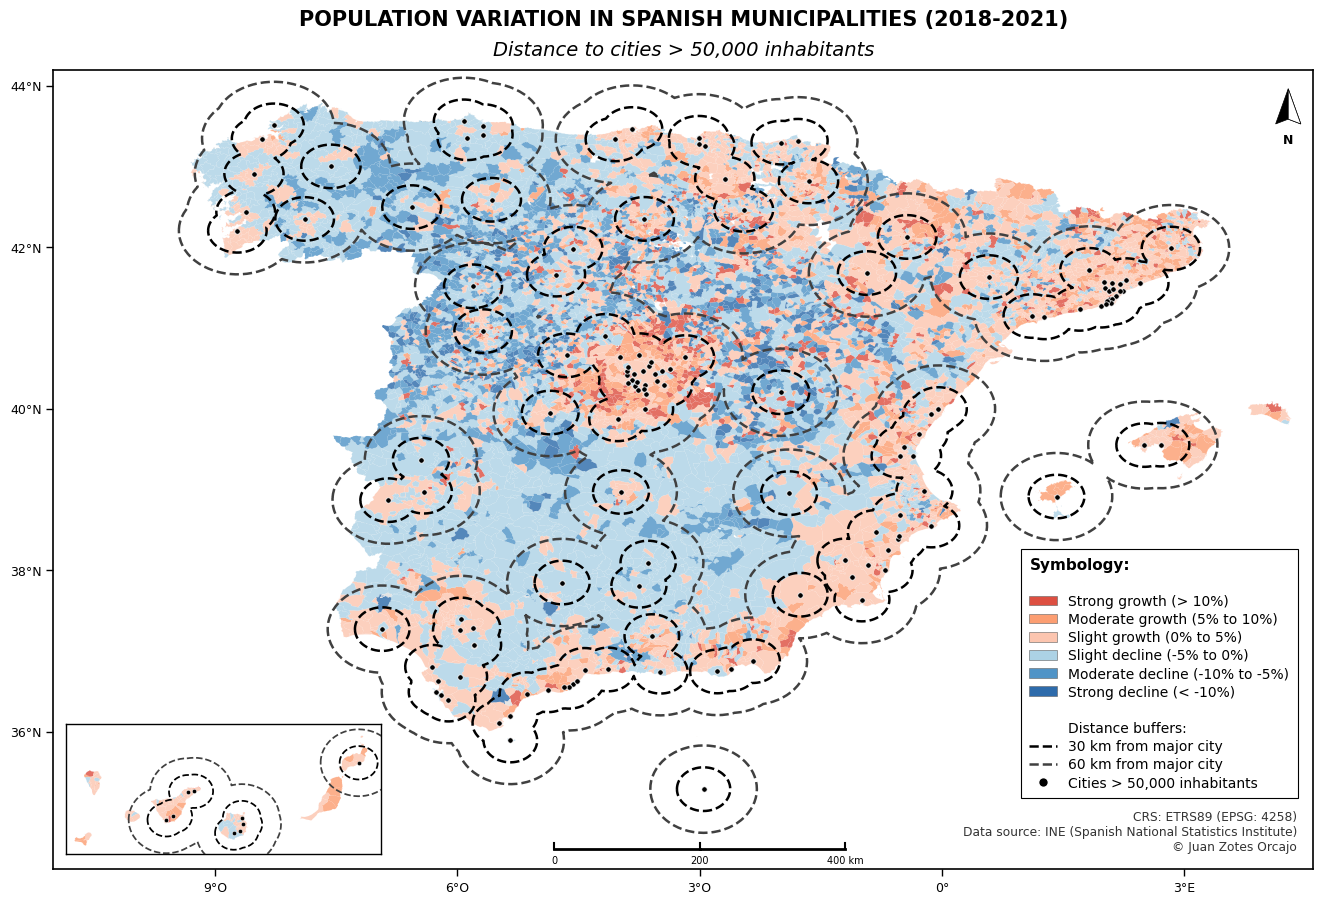

In [13]:
create_population_map(
    gdf_map=gdf_map_2018_2021,
    gdf_cities_pen=gdf_cities_pen_2021,
    gdf_cities_can=gdf_cities_can_2021,
    buffers=buffers_2021,
    period_name='2018-2021',
    output_path=OUTPUT_DIR / 'map_2018_2021_population_variation.png',
    author_name="Juan Zotes Orcajo"
)

✓ Saved: map_2021_2024_population_variation.png


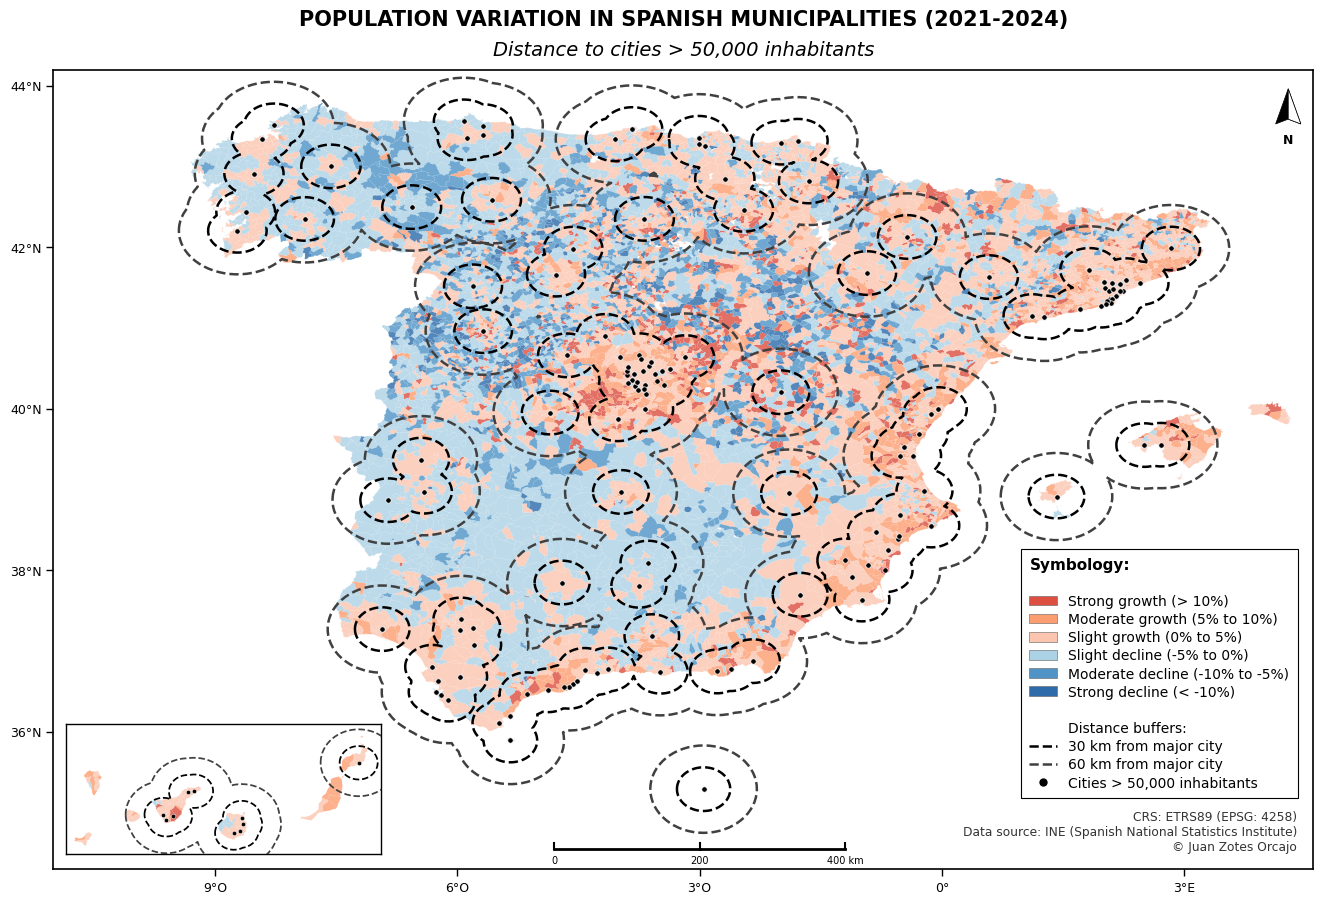

In [14]:
create_population_map(
    gdf_map=gdf_map_2021_2024,
    gdf_cities_pen=gdf_cities_pen_2024,
    gdf_cities_can=gdf_cities_can_2024,
    buffers=buffers_2024,
    period_name='2021-2024',
    output_path=OUTPUT_DIR / 'map_2021_2024_population_variation.png',
    author_name="Juan Zotes Orcajo"
)